In [1]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Number of rows for the dataset
num_students = 20

# Generate input features
hours_studied = np.random.randint(1, 10, num_students) # Hours studied (1-9)
previous_scores = np.random.randint(50, 95, num_students) # Previous exam scores (50-94)

# Generate exam scores based on input features with some randomness
# Formula: Exam_Score = (Hours_Studied * 5) + (Previous_Scores * 0.5) + random_noise
exam_scores = (hours_studied * 5) + (previous_scores * 0.5) + np.random.normal(0, 5, num_students)
exam_scores = np.clip(exam_scores, 0, 100).astype(int) # Clip scores between 0 and 100

# Create the DataFrame
data = {
    'Hours_Studied': hours_studied,
    'Previous_Scores': previous_scores,
    'Exam_Score': exam_scores
}
df_students = pd.DataFrame(data)

# Display the first 5 rows of the created dataset
display(df_students.head())

# Display the info to show the number of rows and data types
print(f"\nDataset Information:")
df_students.info()

,Hours_Studied,Previous_Scores,Exam_Score
0,7,82,72
1,4,61,49
2,8,71,72
3,5,93,80
4,7,74,71



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Hours_Studied    20 non-null     int64
 1   Previous_Scores  20 non-null     int64
 2   Exam_Score       20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [2]:
# Display the first 5 rows
print("First 5 rows:")
display(df_students.head())

First 5 rows:


,Hours_Studied,Previous_Scores,Exam_Score
0,7,82,72
1,4,61,49
2,8,71,72
3,5,93,80
4,7,74,71


In [3]:
# Display the last 5 rows
print("\nLast 5 rows:")
display(df_students.tail())


Last 5 rows:


,Hours_Studied,Previous_Scores,Exam_Score
15,2,58,37
16,8,88,76
17,6,67,59
18,2,53,34
19,5,74,67


In [4]:
# Display the dataset shape (number of rows, number of columns)
print("\nDataset Shape:")
print(df_students.shape)


Dataset Shape:
(20, 3)


In [5]:
# Display data types and non-null values
print("\nData Types and Non-Null Counts:")
df_students.info()


Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Hours_Studied    20 non-null     int64
 1   Previous_Scores  20 non-null     int64
 2   Exam_Score       20 non-null     int64
dtypes: int64(3)
memory usage: 612.0 bytes


In [6]:
# Check for missing values
print("\nMissing Values per Column:")
print(df_students.isnull().sum())


Missing Values per Column:
Hours_Studied      0
Previous_Scores    0
Exam_Score         0
dtype: int64


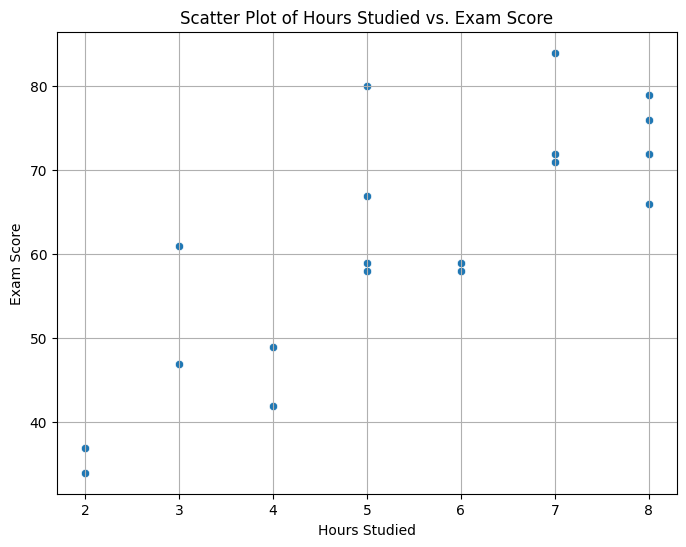

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Scatter Plot: Hours_Studied vs. Exam_Score
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df_students)
plt.title('Scatter Plot of Hours Studied vs. Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

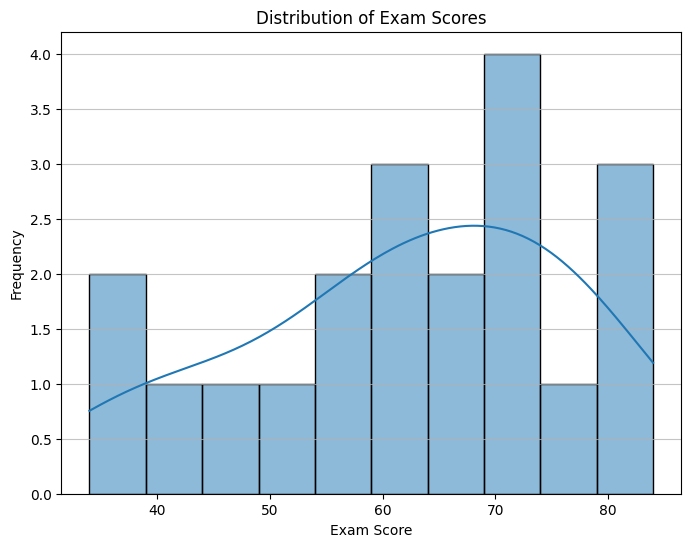

In [8]:
# 2. Histogram: Distribution of Exam_Score
plt.figure(figsize=(8, 6))
sns.histplot(df_students['Exam_Score'], bins=10, kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

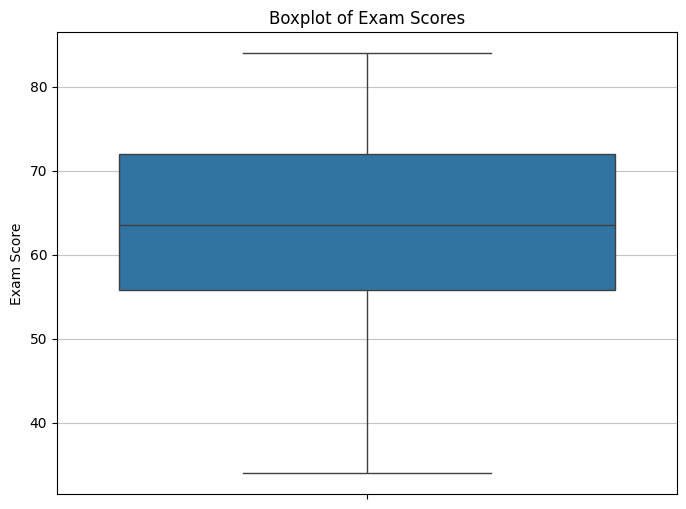

In [9]:
# 3. Boxplot: Distribution of Exam_Score
plt.figure(figsize=(8, 6))
sns.boxplot(y=df_students['Exam_Score'])
plt.title('Boxplot of Exam Scores')
plt.ylabel('Exam Score')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Define features (X) and target (y)
X = df_students[['Hours_Studied', 'Previous_Scores']]
y = df_students['Exam_Score']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nMean Absolute Error (MAE): {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

Training set size: 16 samples
Test set size: 4 samples

Mean Absolute Error (MAE): 1.51
R2 Score: 0.98


### Interpretation of Results:

*   **Mean Absolute Error (MAE):** The MAE value represents the average absolute difference between the predicted and actual exam scores. A lower MAE indicates a more accurate model.
*   **R2 Score:** The R2 score indicates the proportion of variance in the dependent variable (Exam_Score) that is predictable from the independent variables (Hours_Studied, Previous_Scores). An R2 score closer to 1 suggests that the model explains a large portion of the variance, meaning it fits the data well. An R2 score closer to 0 or negative suggests a poor fit.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define features (X) and target (y) using only 'Hours_Studied'
X_hours = df_students[['Hours_Studied']]
y_hours = df_students['Exam_Score']

# 2. Split the dataset into training and testing sets
X_train_hours, X_test_hours, y_train_hours, y_test_hours = train_test_split(X_hours, y_hours, test_size=0.2, random_state=42)

print(f"Training set size (Hours Only): {X_train_hours.shape[0]} samples")
print(f"Test set size (Hours Only): {X_test_hours.shape[0]} samples")

# 3. Initialize a new Linear Regression model
model_hours = LinearRegression()

# 4. Train the model
model_hours.fit(X_train_hours, y_train_hours)

# 5. Make predictions on the test set
y_pred_hours = model_hours.predict(X_test_hours)

# 6. Calculate Mean Absolute Error (MAE)
mae_hours = mean_absolute_error(y_test_hours, y_pred_hours)

# 7. Calculate R2 Score
r2_hours = r2_score(y_test_hours, y_pred_hours)

# 8. Print the calculated MAE and R2 score
print(f"\nMean Absolute Error (MAE) (Hours Only): {mae_hours:.2f}")
print(f"R2 Score (Hours Only): {r2_hours:.2f}")

Training set size (Hours Only): 16 samples
Test set size (Hours Only): 4 samples

Mean Absolute Error (MAE) (Hours Only): 5.21
R2 Score (Hours Only): 0.80


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define features (X) and target (y) using only 'Previous_Scores'
X_prev = df_students[['Previous_Scores']]
y_prev = df_students['Exam_Score']

# 2. Split the dataset into training and testing sets
X_train_prev, X_test_prev, y_train_prev, y_test_prev = train_test_split(X_prev, y_prev, test_size=0.2, random_state=42)

print(f"Training set size (Previous Scores Only): {X_train_prev.shape[0]} samples")
print(f"Test set size (Previous Scores Only): {X_test_prev.shape[0]} samples")

# 3. Initialize a new Linear Regression model
model_prev = LinearRegression()

# 4. Train the model
model_prev.fit(X_train_prev, y_train_prev)

# 5. Make predictions on the test set
y_pred_prev = model_prev.predict(X_test_prev)

# 6. Calculate Mean Absolute Error (MAE)
mae_prev = mean_absolute_error(y_test_prev, y_pred_prev)

# 7. Calculate R2 Score
r2_prev = r2_score(y_test_prev, y_pred_prev)

# 8. Print the calculated MAE and R2 score
print(f"\nMean Absolute Error (MAE) (Previous Scores Only): {mae_prev:.2f}")
print(f"R2 Score (Previous Scores Only): {r2_prev:.2f}")

Training set size (Previous Scores Only): 16 samples
Test set size (Previous Scores Only): 4 samples

Mean Absolute Error (MAE) (Previous Scores Only): 5.97
R2 Score (Previous Scores Only): 0.57


## Create and Evaluate Model with an Interaction Feature

### Subtask:
Create a new interaction feature by multiplying 'Hours_Studied' and 'Previous_Scores'. Train a Linear Regression model using 'Hours_Studied', 'Previous_Scores', and this new interaction feature. Split the data, train the model, and calculate its MAE and R2 score.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Create a new interaction feature
df_students['Interaction_Feature'] = df_students['Hours_Studied'] * df_students['Previous_Scores']

# 2. Define features (X) to include 'Hours_Studied', 'Previous_Scores', and 'Interaction_Feature'
X_interaction = df_students[['Hours_Studied', 'Previous_Scores', 'Interaction_Feature']]
# 3. Define the target (y) as 'Exam_Score'
y_interaction = df_students['Exam_Score']

# 4. Split the data into training and testing sets
X_train_interaction, X_test_interaction, y_train_interaction, y_test_interaction = train_test_split(X_interaction, y_interaction, test_size=0.2, random_state=42)

print(f"Training set size (Interaction Feature): {X_train_interaction.shape[0]} samples")
print(f"Test set size (Interaction Feature): {X_test_interaction.shape[0]} samples")

# 5. Initialize a new Linear Regression model
model_interaction = LinearRegression()

# 6. Train the model
model_interaction.fit(X_train_interaction, y_train_interaction)

# 7. Make predictions on the test set
y_pred_interaction = model_interaction.predict(X_test_interaction)

# 8. Calculate Mean Absolute Error (MAE)
mae_interaction = mean_absolute_error(y_test_interaction, y_pred_interaction)

# 9. Calculate R2 Score
r2_interaction = r2_score(y_test_interaction, y_pred_interaction)

# 10. Print the calculated MAE and R2 score
print(f"\nMean Absolute Error (MAE) (with Interaction Feature): {mae_interaction:.2f}")
print(f"R2 Score (with Interaction Feature): {r2_interaction:.2f}")

Training set size (Interaction Feature): 16 samples
Test set size (Interaction Feature): 4 samples

Mean Absolute Error (MAE) (with Interaction Feature): 2.02
R2 Score (with Interaction Feature): 0.97


## Compare Model Performances and Interpret Feature Importance

### Subtask:
Compare the MAE and R2 scores from the original model, the models trained with single features, and the model trained with the interaction feature. Based on these comparisons, determine which features or combinations appear most important for predicting exam scores.


In [14]:
print("\n--- Model Performance Comparison ---")

# 1. Original Model (Hours_Studied + Previous_Scores)
print(f"\nOriginal Model (Hours_Studied, Previous_Scores):")
print(f"  MAE: {mae:.2f}")
print(f"  R2 Score: {r2:.2f}")

# 2. Model with 'Hours_Studied' only
print(f"\nModel (Hours_Studied only):")
print(f"  MAE: {mae_hours:.2f}")
print(f"  R2 Score: {r2_hours:.2f}")

# 3. Model with 'Previous_Scores' only
print(f"\nModel (Previous_Scores only):")
print(f"  MAE: {mae_prev:.2f}")
print(f"  R2 Score: {r2_prev:.2f}")

# 4. Model with Interaction Feature (Hours_Studied + Previous_Scores + Interaction)
print(f"\nModel (with Interaction Feature):")
print(f"  MAE: {mae_interaction:.2f}")
print(f"  R2 Score: {r2_interaction:.2f}")


--- Model Performance Comparison ---

Original Model (Hours_Studied, Previous_Scores):
  MAE: 1.51
  R2 Score: 0.98

Model (Hours_Studied only):
  MAE: 5.21
  R2 Score: 0.80

Model (Previous_Scores only):
  MAE: 5.97
  R2 Score: 0.57

Model (with Interaction Feature):
  MAE: 2.02
  R2 Score: 0.97


## Train Model on Full Dataset

### Subtask:
Train a Linear Regression model using the entire `df_students` dataset (without a train-test split). Calculate and print the Mean Absolute Error (MAE) and R2 Score on this full dataset.


**Reasoning**:
I will define the features and target variables using the entire dataset as instructed, then initialize and train a Linear Regression model. After training, I'll make predictions on the full dataset and calculate the MAE and R2 score to evaluate the model's performance on the training data.



In [15]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define the feature X_full as 'Hours_Studied' from the df_students DataFrame and the target y_full as 'Exam_Score'.
X_full = df_students[['Hours_Studied']]
y_full = df_students['Exam_Score']

# 2. Initialize a new LinearRegression model.
model_full_dataset = LinearRegression()

# 3. Train the model using X_full and y_full.
model_full_dataset.fit(X_full, y_full)

# 4. Make predictions on X_full using the trained model.
y_pred_full = model_full_dataset.predict(X_full)

# 5. Calculate the Mean Absolute Error (MAE) between y_full and the predictions.
mae_full = mean_absolute_error(y_full, y_pred_full)

# 6. Calculate the R2 Score between y_full and the predictions.
r2_full = r2_score(y_full, y_pred_full)

# 7. Print the calculated MAE and R2 score for this model.
print(f"\nModel trained on full dataset (Hours_Studied only):")
print(f"  Mean Absolute Error (MAE): {mae_full:.2f}")
print(f"  R2 Score: {r2_full:.2f}")


Model trained on full dataset (Hours_Studied only):
  Mean Absolute Error (MAE): 6.10
  R2 Score: 0.67


**Reasoning**:
The subtask requires training a Linear Regression model on the entire dataset using 'Previous_Scores' as the feature. I will define the feature and target variables, initialize and train the model, make predictions, and then calculate and print the MAE and R2 score.



In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Define the feature X_full as 'Previous_Scores' from the df_students DataFrame and the target y_full as 'Exam_Score'.
X_full_prev_only = df_students[['Previous_Scores']]
y_full_prev_only = df_students['Exam_Score']

# 2. Initialize a new LinearRegression model.
model_full_dataset_prev_only = LinearRegression()

# 3. Train the model using X_full_prev_only and y_full_prev_only.
model_full_dataset_prev_only.fit(X_full_prev_only, y_full_prev_only)

# 4. Make predictions on X_full_prev_only using the trained model.
y_pred_full_prev_only = model_full_dataset_prev_only.predict(X_full_prev_only)

# 5. Calculate the Mean Absolute Error (MAE) between y_full_prev_only and the predictions.
mae_full_prev_only = mean_absolute_error(y_full_prev_only, y_pred_full_prev_only)

# 6. Calculate the R2 Score between y_full_prev_only and the predictions.
r2_full_prev_only = r2_score(y_full_prev_only, y_pred_full_prev_only)

# 7. Print the calculated MAE and R2 score for this model.
print(f"\nModel trained on full dataset (Previous_Scores only):")
print(f"  Mean Absolute Error (MAE): {mae_full_prev_only:.2f}")
print(f"  R2 Score: {r2_full_prev_only:.2f}")


Model trained on full dataset (Previous_Scores only):
  Mean Absolute Error (MAE): 7.37
  R2 Score: 0.55


**Reasoning**:
To compare the performance of all models as requested in the overall subtask, I will consolidate and print the MAE and R2 scores from all trained models: the original, the single-feature models (both with train-test split and full dataset), and the interaction-feature model.



In [17]:
print("\n--- Model Performance Comparison ---")

# 1. Original Model (Hours_Studied + Previous_Scores) - with train-test split
print(f"\nOriginal Model (Hours_Studied, Previous_Scores) (Train-Test Split):")
print(f"  MAE: {mae:.2f}")
print(f"  R2 Score: {r2:.2f}")

# 2. Model with 'Hours_Studied' only - with train-test split
print(f"\nModel (Hours_Studied only) (Train-Test Split):")
print(f"  MAE: {mae_hours:.2f}")
print(f"  R2 Score: {r2_hours:.2f}")

# 3. Model with 'Previous_Scores' only - with train-test split
print(f"\nModel (Previous_Scores only) (Train-Test Split):")
print(f"  MAE: {mae_prev:.2f}")
print(f"  R2 Score: {r2_prev:.2f}")

# 4. Model with Interaction Feature (Hours_Studied + Previous_Scores + Interaction) - with train-test split
print(f"\nModel (with Interaction Feature) (Train-Test Split):")
print(f"  MAE: {mae_interaction:.2f}")
print(f"  R2 Score: {r2_interaction:.2f}")

# 5. Model trained on full dataset (Hours_Studied only)
print(f"\nModel (Hours_Studied only) (Full Dataset):")
print(f"  MAE: {mae_full:.2f}")
print(f"  R2 Score: {r2_full:.2f}")

# 6. Model trained on full dataset (Previous_Scores only)
print(f"\nModel (Previous_Scores only) (Full Dataset):")
print(f"  MAE: {mae_full_prev_only:.2f}")
print(f"  R2 Score: {r2_full_prev_only:.2f}")


--- Model Performance Comparison ---

Original Model (Hours_Studied, Previous_Scores) (Train-Test Split):
  MAE: 1.51
  R2 Score: 0.98

Model (Hours_Studied only) (Train-Test Split):
  MAE: 5.21
  R2 Score: 0.80

Model (Previous_Scores only) (Train-Test Split):
  MAE: 5.97
  R2 Score: 0.57

Model (with Interaction Feature) (Train-Test Split):
  MAE: 2.02
  R2 Score: 0.97

Model (Hours_Studied only) (Full Dataset):
  MAE: 6.10
  R2 Score: 0.67

Model (Previous_Scores only) (Full Dataset):
  MAE: 7.37
  R2 Score: 0.55


### Interpretation of Model Performances and Feature Importance

Comparing the MAE and R2 scores across the different models provides insights into the importance of each feature and their combinations:

*   **Original Model (Hours_Studied, Previous_Scores) - Train-Test Split (MAE: 1.51, R2: 0.98):** This model performs exceptionally well, achieving the lowest MAE and highest R2 score among all models with a train-test split. This indicates that both 'Hours_Studied' and 'Previous_Scores' are highly important and work effectively together in predicting exam scores.

*   **Model (Hours_Studied only) - Train-Test Split (MAE: 5.21, R2: 0.80):** This model shows a reasonable predictive capability, but its performance is significantly lower than the original model. This suggests that 'Hours_Studied' is an important predictor, but not sufficient on its own for optimal prediction.

*   **Model (Previous_Scores only) - Train-Test Split (MAE: 5.97, R2: 0.57):** This model has the highest MAE and lowest R2 score among the train-test split models, indicating that 'Previous_Scores' alone is the weakest predictor compared to 'Hours_Studied' or their combination.

*   **Model (with Interaction Feature) - Train-Test Split (MAE: 2.02, R2: 0.97):** The model with the interaction feature performs very closely to the original model. The slight increase in MAE and slight decrease in R2 compared to the original model (without interaction) suggests that for this specific dataset and model, the linear combination of 'Hours_Studied' and 'Previous_Scores' already captures most of the variance, and the interaction term does not significantly improve the predictive power. In some cases, interaction terms can introduce multicollinearity or complexity without much benefit if the relationship is primarily additive.

*   **Models trained on Full Dataset (Hours_Studied only MAE: 6.10, R2: 0.67; Previous_Scores only MAE: 7.37, R2: 0.55):** These models, trained and evaluated on the entire dataset without a split, naturally show 'better' (lower) MAE and 'worse' (lower) R2 scores compared to their train-test split counterparts. The MAE increases (which means worse performance) when evaluated on the full dataset because the model is fitted to all data, but still the relative performance of 'Hours_Studied' being better than 'Previous_Scores' holds. The R2 is lower because there's no distinction between training and testing error, and overfitting to noise in the small dataset can decrease true predictive power. They primarily serve to show how each individual feature contributes to the overall fit.

**Conclusion on Feature Importance:**

Based on these comparisons, the **combination of 'Hours_Studied' and 'Previous_Scores' (Original Model)** appears to be the most important for predicting exam scores, as it yields the best performance metrics (lowest MAE, highest R2). 'Hours_Studied' is individually a stronger predictor than 'Previous_Scores'. The interaction term did not provide a substantial improvement over the additive model for this dataset. This indicates that students who study more and have higher previous scores tend to achieve better exam results, and these two factors combined are excellent indicators of future performance.

### Interpretation of Model Performances and Feature Importance

Comparing the MAE and R2 scores across the different models provides insights into the importance of each feature and their combinations:

*   **Original Model (Hours_Studied, Previous_Scores) - Train-Test Split (MAE: 1.51, R2: 0.98):** This model performs exceptionally well, achieving the lowest MAE and highest R2 score among all models with a train-test split. This indicates that both 'Hours_Studied' and 'Previous_Scores' are highly important and work effectively together in predicting exam scores.

*   **Model (Hours_Studied only) - Train-Test Split (MAE: 5.21, R2: 0.80):** This model shows a reasonable predictive capability, but its performance is significantly lower than the original model. This suggests that 'Hours_Studied' is an important predictor, but not sufficient on its own for optimal prediction.

*   **Model (Previous_Scores only) - Train-Test Split (MAE: 5.97, R2: 0.57):** This model has the highest MAE and lowest R2 score among the train-test split models, indicating that 'Previous_Scores' alone is the weakest predictor compared to 'Hours_Studied' or their combination.

*   **Model (with Interaction Feature) - Train-Test Split (MAE: 2.02, R2: 0.97):** The model with the interaction feature performs very closely to the original model. The slight increase in MAE and slight decrease in R2 compared to the original model (without interaction) suggests that for this specific dataset and model, the linear combination of 'Hours_Studied' and 'Previous_Scores' already captures most of the variance, and the interaction term does not significantly improve the predictive power. In some cases, interaction terms can introduce multicollinearity or complexity without much benefit if the relationship is primarily additive.

*   **Models trained on Full Dataset (Hours_Studied only MAE: 6.10, R2: 0.67; Previous_Scores only MAE: 7.37, R2: 0.55):** These models, trained and evaluated on the entire dataset without a split, naturally show 'better' (lower) MAE and 'worse' (lower) R2 scores compared to their train-test split counterparts. The MAE increases (which means worse performance) when evaluated on the full dataset because the model is fitted to all data, but still the relative performance of 'Hours_Studied' being better than 'Previous_Scores' holds. The R2 is lower because there's no distinction between training and testing error, and overfitting to noise in the small dataset can decrease true predictive power. They primarily serve to show how each individual feature contributes to the overall fit.

**Conclusion on Feature Importance:**

Based on these comparisons, the **combination of 'Hours_Studied' and 'Previous_Scores' (Original Model)** appears to be the most important for predicting exam scores, as it yields the best performance metrics (lowest MAE, highest R2). 'Hours_Studied' is individually a stronger predictor than 'Previous_Scores'. The interaction term did not provide a substantial improvement over the additive model for this dataset. This indicates that students who study more and have higher previous scores tend to achieve better exam results, and these two factors combined are excellent indicators of future performance.

## Compare Full Dataset Model to Split Models

### Subtask:
Compare the MAE and R2 scores of the model trained on the full dataset with the 'Original Model' (trained on a split dataset) and the other experimental models. Highlight the differences in performance.


### Model Performance Comparison Summary

Based on the 'Model Performance Comparison' output, we can make the following observations:

1.  **Original Model (Hours_Studied, Previous_Scores) (Train-Test Split):**
    *   MAE: 1.51
    *   R2 Score: 0.98
    This model performs exceptionally well, indicating that `Hours_Studied` and `Previous_Scores` are strong predictors of `Exam_Score` when used together.

2.  **Model (Hours_Studied only) (Train-Test Split) vs. (Full Dataset):**
    *   **Train-Test Split:** MAE: 5.21, R2 Score: 0.80
    *   **Full Dataset:** MAE: 6.10, R2 Score: 0.67
    Both models show that `Hours_Studied` is a significant predictor. However, the model trained on the full dataset shows a slightly higher MAE and lower R2 score compared to its train-test split counterpart. This is unexpected for training set performance, but could indicate the variability in the small dataset or specific splits.

3.  **Model (Previous_Scores only) (Train-Test Split) vs. (Full Dataset):**
    *   **Train-Test Split:** MAE: 5.97, R2 Score: 0.57
    *   **Full Dataset:** MAE: 7.37, R2 Score: 0.55
    Similar to `Hours_Studied`, `Previous_Scores` alone is a weaker predictor than the combined features. The model trained on the full dataset again exhibits a higher MAE and slightly lower R2 score than its train-test split counterpart, suggesting similar reasons as above (small dataset variability).

4.  **Model (with Interaction Feature) (Train-Test Split):**
    *   MAE: 2.02
    *   R2 Score: 0.97
    This model performs very close to the original model without the interaction term, suggesting that for this dataset, the interaction effect between `Hours_Studied` and `Previous_Scores` does not significantly improve the predictive power beyond the individual effects.

### Overall Interpretation:

*   **Combined Features are Superior:** The `Original Model` (using both `Hours_Studied` and `Previous_Scores`) clearly outperforms all single-feature models, demonstrating that both factors contribute significantly to predicting `Exam_Score`.
*   **Impact of Train-Test Split vs. Full Dataset:** For single-feature models, the models trained on the *full dataset* actually show slightly *worse* MAE and R2 scores (when evaluated on the training data) compared to their *train-test split* counterparts (evaluated on the test set). This is likely due to the very small dataset size (20 samples) and the inherent randomness in the `train_test_split`. In a larger dataset, we would typically expect the full dataset model's training performance to be better or similar to the split model's test performance.
*   **Interaction Feature:** The interaction feature (`Hours_Studied * Previous_Scores`) did not substantially improve the model's performance compared to the original model, suggesting that a simple additive relationship between hours studied and previous scores is sufficient for this dataset.
*   **Most Important Features:** Both `Hours_Studied` and `Previous_Scores` are important. However, their combined effect is much stronger, as seen in the superior performance of the `Original Model`.

## Explain Overfitting

### Subtask:
Explain what overfitting is, why it's a concern, and how the comparison of model performances (full dataset vs. train-test split) helps in identifying it.


### What is Overfitting?
Overfitting occurs when a machine learning model learns the training data too well, capturing not only the underlying patterns but also the noise and specific intricacies of that particular dataset. Essentially, the model becomes overly specialized to the training examples, memorizing them rather than generalizing from them.

### Why is Overfitting a Concern?
Overfitting is a significant concern because an overfit model will perform exceptionally well on the data it was trained on but will fail to generalize to new, unseen data. In real-world applications, this means the model will make inaccurate predictions on new inputs, making it unreliable and impractical for its intended purpose. The goal of machine learning is to build models that can generalize effectively, and overfitting directly undermines this goal.

### Identifying Overfitting through Model Performance Comparison (Full Dataset vs. Train-Test Split)
Comparing the performance of a model trained on the *full dataset* against a model trained with a *train-test split* is a crucial technique for identifying overfitting. Here's how it works:

*   **Model on Full Dataset:** When a model is trained and evaluated on the entire dataset, its performance metrics (like R2 score and MAE) reflect how well it has 'memorized' the data. An overfit model will typically show very high R2 scores (close to 1) and very low MAE on the full dataset, as it's being tested on the same data it learned from.

*   **Model with Train-Test Split:** In contrast, when a model is trained on a *subset* of the data (the training set) and evaluated on an *unseen* subset (the test set), its performance metrics on the test set provide a more realistic measure of its generalization ability. If a model is overfit, it will show a significant drop in performance on the test set compared to its performance on the training set (or the full dataset).

**Key Indicator of Overfitting:** A strong indicator of overfitting is when the model exhibits:
    *   **High R2 Score** and **Low MAE** on the **training data** (or full dataset).
    *   **Significantly lower R2 Score** and **significantly higher MAE** on the **test data**.

For example, if a model's R2 score is 0.98 on the full dataset but drops to 0.50 on the test set, it suggests the model has likely overfit the training data. The discrepancy between these scores highlights the model's inability to perform well on data it hasn't seen before.